# ITSM Incident Priority Prediction (PRCL-0012)
## Goal: Predict High Priority (P1, P2) Tickets Before They Occur

# SQl Connector for data fetching

In [597]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import vizion as vz
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [598]:
df = pd.read_csv("itsm_dataset.csv")
df.shape

(46606, 25)

In [599]:
vz.help_steps()

=== VIZION CLASS STEP-BY-STEP GUIDE ===
STEP 1: Load your dataset into a pandas DataFrame (df).
STEP 2: Quick overview of data:
        Vizion.quick_summary(df)  # basic stats and missing info
STEP 3: Check missing values in detail:
        Vizion.missing_value_summary(df)
STEP 4: Set global column types (numeric, categorical, missing):
        Vizion.get_column_types(df)
STEP 5: Handle missing values:
        df_clean, report = Vizion.handle_missing(df)  # drops/fills missing
STEP 6: Explore numeric columns with visual EDA:
        Vizion.plot_numeric_eda(df_clean)  # hist, box, kde, scatter
STEP 7: Explore categorical columns with visual EDA:
        Vizion.plot_categorical_eda(df_clean)  # count, bar, box, pie
STEP 8: Detect and handle outliers:
        df_clean = Vizion.handle_outliers(df_clean)  # cap/remove outliers
STEP 9: After EDA, you can perform feature engineering, encoding, scaling etc.
STEP 10: Build models (optional guidance):
        Use 'next_steps(df_clean, target="yo

# Missing Values

In [600]:
vz.quick_summary(df)

===== SIMPLE DATA SUMMARY =====
Rows       : 46606
Columns    : 25
Numeric    : 6
Categorical: 19
Datetime   : 0
Missing columns: 12
Duplicated rows: 0

Top Missing Columns (%):
  - Related_Change: 98.8%
  - No_of_Related_Changes: 98.8%
  - No_of_Related_Incidents: 97.38%
  - Reopen_Time: 95.1%
  - Resolved_Time: 3.82%
  - Priority: 2.96%
  - Closure_Code: 0.99%
  - CI_Cat: 0.24%
  - CI_Subcat: 0.24%
  - No_of_Related_Interactions: 0.24%

Top Missing Categorical Columns (%):
  - Related_Change: 98.8%
  - Reopen_Time: 95.1%
  - Resolved_Time: 3.82%
  - Closure_Code: 0.99%
  - CI_Subcat: 0.24%
  - CI_Cat: 0.24%


In [601]:
df.columns

Index(['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'Incident_ID', 'Status',
       'Impact', 'Urgency', 'Priority', 'number_cnt', 'Category', 'KB_number',
       'Alert_Status', 'No_of_Reassignments', 'Open_Time', 'Reopen_Time',
       'Resolved_Time', 'Close_Time', 'Handle_Time_hrs', 'Closure_Code',
       'No_of_Related_Interactions', 'Related_Interaction',
       'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change'],
      dtype='object')

In [602]:
vz.missing_value_summary(df)

,Column,Data Type,Missing Count,Missing %,Recommended Action
0,Related_Change,object,46046,98.798438,"Fill with ""None"" (absence meaningful)"
1,No_of_Related_Changes,float64,46046,98.798438,Consider dropping or fill with 0
2,No_of_Related_Incidents,float64,45384,97.378020,Consider dropping or fill with 0
3,Reopen_Time,object,44322,95.099343,"Fill with ""None"" (absence meaningful)"
4,Resolved_Time,object,1780,3.819251,Fill with mode
5,Priority,float64,1380,2.960992,Fill with median
6,Closure_Code,object,460,0.986997,Fill with mode
7,No_of_Related_Interactions,float64,114,0.244604,Fill with median
8,CI_Cat,object,111,0.238167,Fill with mode
9,CI_Subcat,object,111,0.238167,Fill with mode


### Removing >80% missing values columns

In [603]:
m80=['No_of_Related_Incidents', 'Related_Change', 'No_of_Related_Changes', 'Reopen_Time']
df.drop(m80,axis=1,inplace=True)



# EDA


In [604]:
# assigning type of columns
num_col = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_col = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
mis_col = df.columns[df.isnull().sum() > 0].tolist()


print(df[num_col].shape)
print(df[cat_col].shape)
print(df[mis_col].shape)
print()
df[mis_col].isnull().sum()

(46606, 4)
(46606, 17)
(46606, 8)



CI_Cat                         111
CI_Subcat                      111
Priority                      1380
No_of_Reassignments              1
Resolved_Time                 1780
Handle_Time_hrs                  1
Closure_Code                   460
No_of_Related_Interactions     114
dtype: int64

In [605]:
df['CI_Cat'].unique()

array(['subapplication', 'application', 'computer', nan, 'displaydevice',
       'software', 'storage', 'database', 'hardware', 'officeelectronics',
       'networkcomponents', 'applicationcomponent', 'Phone'], dtype=object)

In [606]:
cat_mis_col = df[mis_col].select_dtypes(include=['object'])
num_mis_col = df[mis_col].select_dtypes(include=['int64','float64'])

In [607]:
# for categorical columns
for col in cat_mis_col:
    df.loc[ : , col] = df[col].fillna(df[col].mode()[0])

# for numerical columns
for col in num_mis_col:
    df.loc[ : , col] = df[col].fillna(df[col].median())

# updating missed columns
mis_col = df.columns[df.isnull().sum() > 0].tolist()
mis_col


[]

#####  no missing values is the df

In [608]:
df = df.replace([""," ",'nan','Null','NULL','null'],'Unknown')
(df == "Unknown").sum()

CI_Name                          0
CI_Cat                           0
CI_Subcat                        0
WBS                              0
Incident_ID                      0
Status                           0
Impact                           0
Urgency                          0
Priority                         0
number_cnt                       0
Category                         0
KB_number                        0
Alert_Status                     0
No_of_Reassignments              0
Open_Time                        0
Resolved_Time                    0
Close_Time                       0
Handle_Time_hrs                  0
Closure_Code                  1590
No_of_Related_Interactions       0
Related_Interaction              0
dtype: int64

## Closure_Code  Column has Unknown string value 


In [609]:
print(df['Closure_Code'].unique())
print()
print(df['Impact'].unique())

['Other' 'Software' 'No error - works as designed' 'Operator error'
 'Unknown' 'Data' 'Referred' 'Hardware' 'Questions' 'User error' 'Inquiry'
 'User manual not used' 'Kwaliteit van de output' 'Overig']

['4' '3' 'NS' '5' '2' '1']


In [610]:
df = df.replace("Unknown", df['Closure_Code'].mode())

#  invalid value in Impact column: NS
df["Impact"] = df["Impact"].replace("NS",df["Impact"].mode()[0]).astype(int)

In [611]:
df["Handle_Time_hrs"].head(4)

0    3,87,16,91,111
1    4,35,47,86,389
2    4,84,31,19,444
3    4,32,18,33,333
Name: Handle_Time_hrs, dtype: object

#### Handle_Time_hrs data is like unformatted data. this should be in hrs

In [612]:
df.drop("Handle_Time_hrs",axis=1,inplace=True)

# Convert to datetime
df['Open_Time'] =   pd.to_datetime(df['Open_Time'], format='%d-%m-%Y %H:%M',errors='coerce')
df['Resolved_Time'] = pd.to_datetime(df['Resolved_Time'], format='%d-%m-%Y %H:%M',errors='coerce')
df['Close_Time']    =  pd.to_datetime(df['Close_Time'], format='%d-%m-%Y %H:%M',errors='coerce')
# the challannge of naT data : my data does not include second so i will not use %S;


df["Handle_Time_hrs"] = (df["Close_Time"] - df["Open_Time"]).dt.total_seconds() / 3600
df["Handle_Time_hrs"].head(3)

0    15312.316667
1    15116.866667
2    15722.616667
Name: Handle_Time_hrs, dtype: float64

In [613]:
print(df['Alert_Status'].value_counts())
# dropping Unless Columns
drop_cols = ["WBS", "Incident_ID","KB_number","Alert_Status"]
df = df.drop(columns=drop_cols, errors="ignore")

Alert_Status
closed    46606
Name: count, dtype: int64


In [614]:
# updating values

num_col = df.select_dtypes(include=[np.number]).columns.tolist()
cat_col = df.select_dtypes(include=['object']).columns.tolist()

# Data Vizualization & Understanding

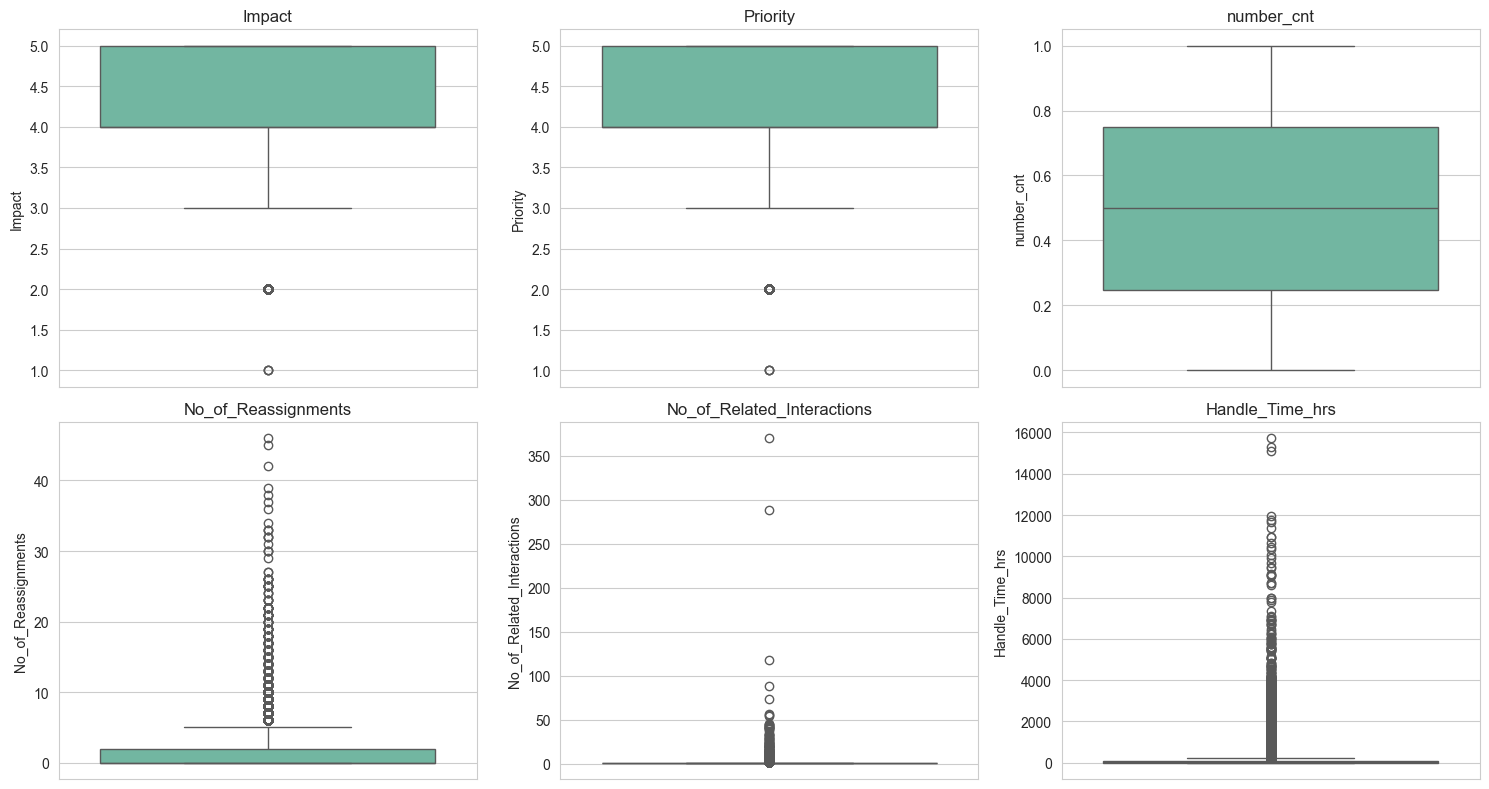

In [615]:
vz.plot_columns(df,num_col,plot_type="box",theme="Set2")

# Handelling Outliers

📦 Backup created as variable 'bkp'
🧮 Processing 4 columns (Skipped 2)

⛔ Skipped Columns (Offline Insights):
   • Impact: Categorical/ordinal variable with 5 unique values.
   • Priority: Categorical/ordinal variable with 5 unique values.


📊 Column: number_cnt
   Skew: 0.00, Outliers: 0 (0.00%)
   Method used: REMOVE, Threshold: 1.5

📊 Column: No_of_Reassignments
   Skew: 4.83, Outliers: 776 (1.67%)
   Method used: REMOVE, Threshold: 3

📊 Column: No_of_Related_Interactions
   Skew: 100.68, Outliers: 3192 (6.96%)
   Method used: REMOVE, Threshold: 3

📊 Column: Handle_Time_hrs
   Skew: 14.11, Outliers: 2855 (6.70%)
   Method used: REMOVE, Threshold: 3


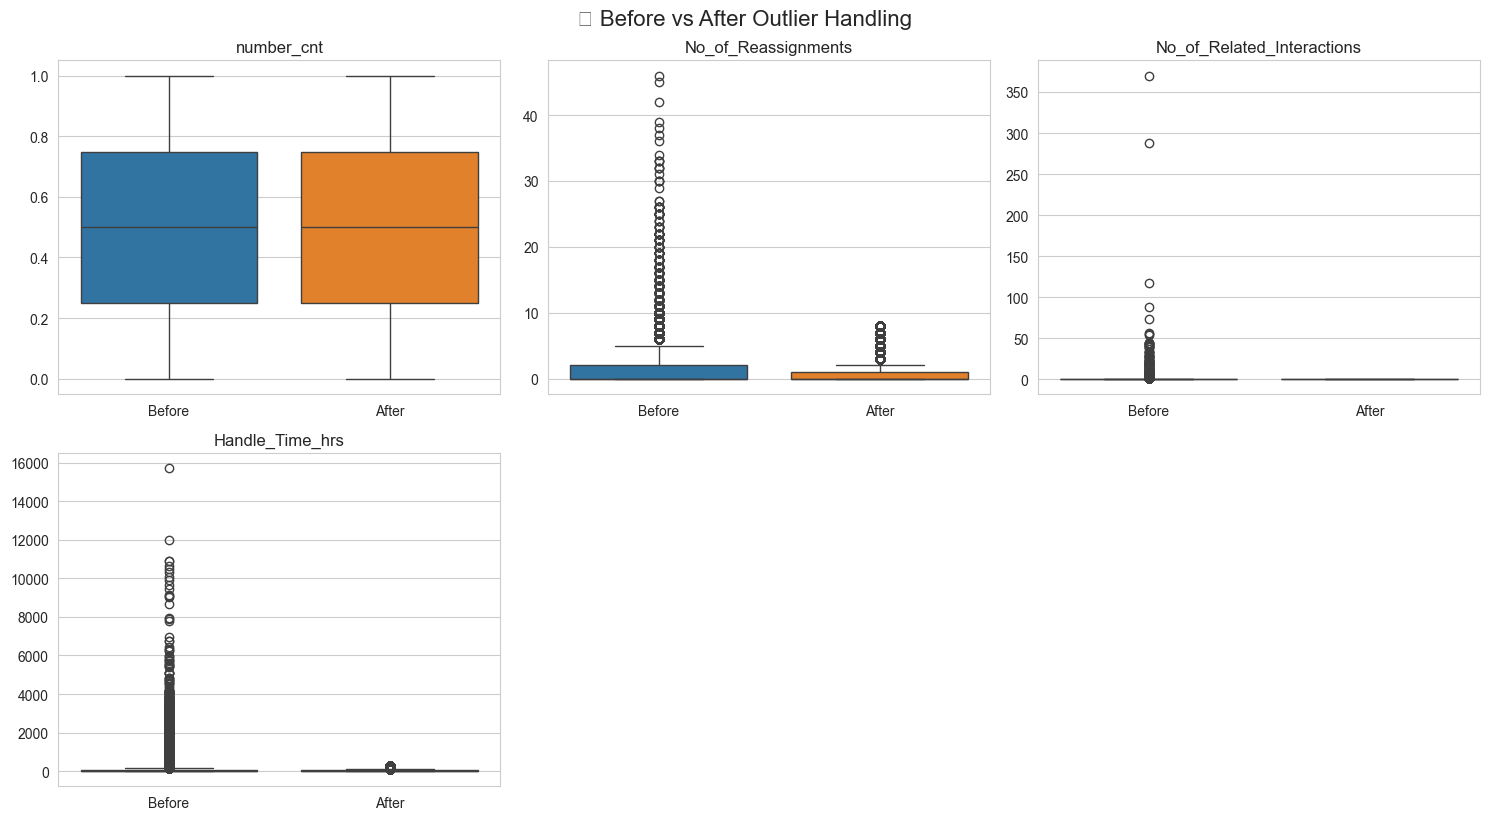


✅ Outlier handling complete!
Final dataset shape: (39783, 17)


,CI_Name,CI_Cat,CI_Subcat,Status,Impact,Urgency,Priority,number_cnt,Category,No_of_Reassignments,Open_Time,Resolved_Time,Close_Time,Closure_Code,No_of_Related_Interactions,Related_Interaction,Handle_Time_hrs
515,APP000005,application,Citrix,Closed,4,4,4.0,0.354084,incident,0.0,2013-09-19 13:31:00,2013-10-01 09:43:00,2013-10-01 09:43:00,Software,1.0,SD0000805,284.200000
528,CBA000014,application,Client Based Application,Closed,4,3,4.0,0.390578,request for information,4.0,2013-09-20 12:51:00,2013-10-02 10:01:00,2013-10-02 10:01:00,Other,1.0,SD0000833,285.166667
537,SBA000263,application,Server Based Application,Closed,5,5,5.0,0.720732,request for information,0.0,2013-09-23 09:21:00,2013-10-02 07:59:00,2013-10-02 07:59:00,Other,1.0,SD0000844,214.633333
538,OVR000078,application,Server Based Application,Closed,3,3,3.0,0.386611,incident,4.0,2013-09-23 09:24:00,2013-10-10 12:53:00,2013-10-01 12:17:00,Software,1.0,SD0000843,194.883333
541,SBA000630,application,Server Based Application,Closed,5,5,5.0,0.350640,request for information,3.0,2013-09-23 11:17:00,2013-10-02 06:51:00,2013-10-02 06:51:00,No error - works as designed,1.0,SD0000862,211.566667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46601,SBA000464,application,Server Based Application,Closed,4,4,4.0,0.231896,incident,0.0,2014-03-31 16:23:00,2014-03-31 16:29:00,2014-03-31 16:29:00,Other,1.0,SD0147021,0.100000
46602,SBA000461,application,Server Based Application,Closed,4,4,4.0,0.805153,incident,0.0,2014-03-31 15:03:00,2014-03-31 15:29:00,2014-03-31 15:29:00,User error,1.0,SD0146967,0.433333
46603,LAP000019,computer,Laptop,Closed,5,5,5.0,0.917466,incident,0.0,2014-03-31 15:28:00,2014-03-31 15:32:00,2014-03-31 15:32:00,Hardware,1.0,SD0146982,0.066667
46604,WBA000058,application,Web Based Application,Closed,4,4,4.0,0.701278,incident,0.0,2014-03-31 15:35:00,2014-03-31 15:42:00,2014-03-31 15:42:00,Software,1.0,SD0146986,0.116667


In [616]:
vz.handle_outliers(df,num_col)

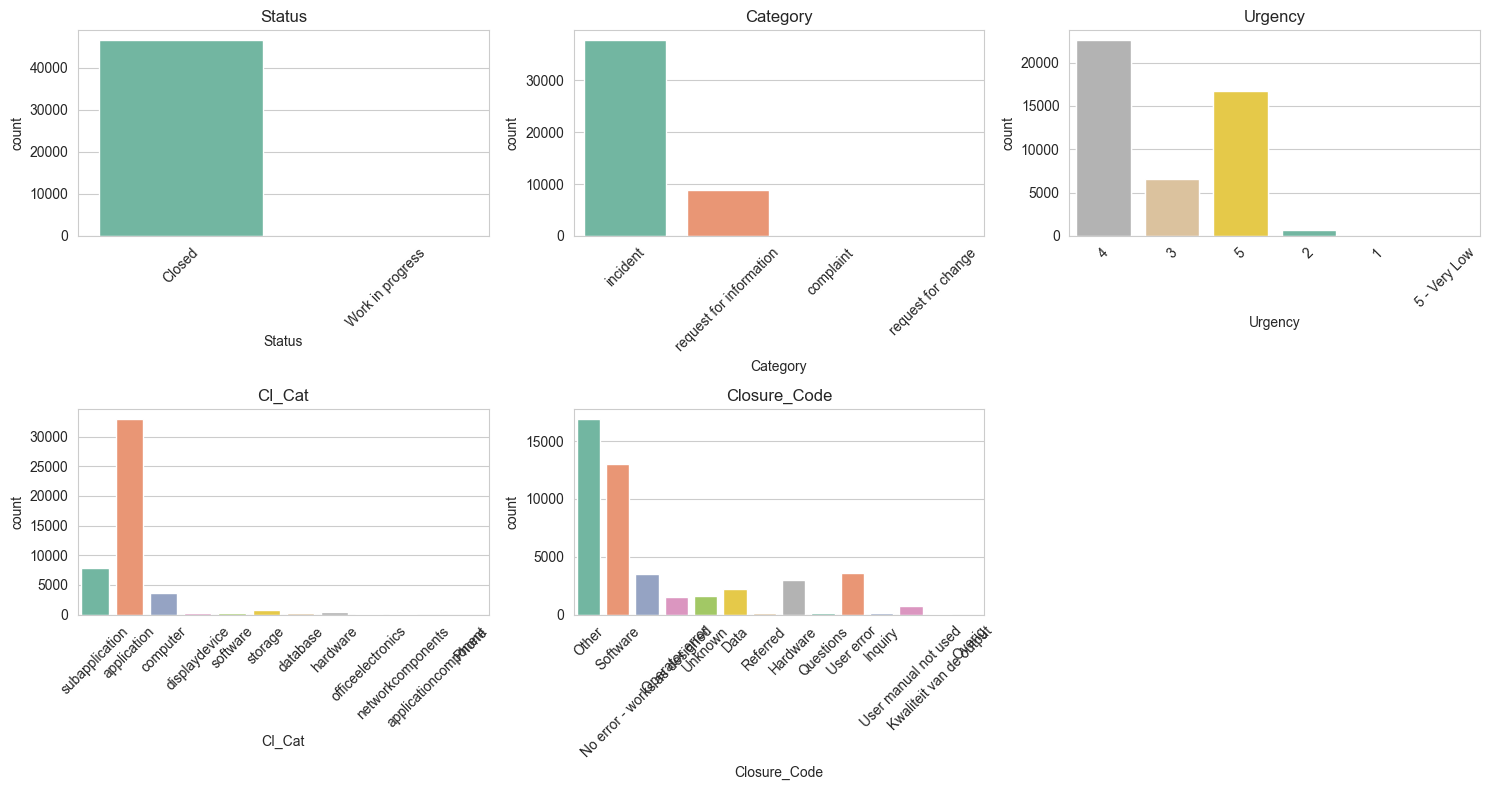

In [617]:
cat_col

# _________________countplot _________________
# Related_Interaction    43060    ❌
# CI_Name                 3019    ❌
# CI_Subcat                 64    ⚠️ (possible)
# Closure_Code              14    ✅
# CI_Cat                    12    ✅
# Urgency                   11    ✅
# Category                   4    ✅
# Status                     2    ✅

vz.plot_columns(df,['Status','Category','Urgency','CI_Cat','Closure_Code'],plot_type="count")

In [618]:
print(df['Status'].value_counts())
print("--------------")
print(df['Category'].value_counts())
print("--------------")
print(df['Related_Interaction'].value_counts())
print("--------------")
print(df['CI_Name'].value_counts())
print("--------------")
print(df['CI_Subcat'].value_counts())

Status
Closed              46597
Work in progress        9
Name: count, dtype: int64
--------------
Category
incident                   37748
request for information     8846
complaint                     11
request for change             1
Name: count, dtype: int64
--------------
Related_Interaction
#MULTIVALUE    3434
#N/B            114
SD0000007         1
SD0000011         1
SD0000017         1
               ... 
SD0147021         1
SD0146967         1
SD0146982         1
SD0146986         1
SD0147088         1
Name: count, Length: 43060, dtype: int64
--------------
CI_Name
SUB000456    3050
SBA000263    2176
SBA000607    1743
SBA000462    1698
WBA000058    1614
             ... 
SBA000480       1
SBA000301       1
LAP001571       1
SBA000575       1
WSR000294       1
Name: count, Length: 3019, dtype: int64
--------------
CI_Subcat
Server Based Application           18922
Web Based Application              15311
Desktop Application                 3876
Laptop                      

#### Status column is highly imbalanced ---> drop()
#### The Column Related_Interaction has placeholder values like #MULTIVALUE and #N/B and the actual interaction IDs appear only once. It has no business meaning, provides no predictive value, and would create high-cardinality noise if encoded.  ---> drop()
#### CI_Name was dropped because it contains over 3000 unique system-generated IDs with no business meaning. Encoding it would create high-cardinality noise and reduce model performance.
#### Why CI_Subcat is useful : It contains meaningful functional groups, This can affect ticket Priority, Urgency, and failure patterns.

In [619]:
df.drop(["Status","Related_Interaction","CI_Name"],axis=1,inplace=True)

In [620]:
for i in df.columns:
    print(i," : ",df[i].unique())
    print()

CI_Cat  :  ['subapplication' 'application' 'computer' 'displaydevice' 'software'
 'storage' 'database' 'hardware' 'officeelectronics' 'networkcomponents'
 'applicationcomponent' 'Phone']

CI_Subcat  :  ['Web Based Application' 'Desktop Application' 'Server Based Application'
 'SAP' 'Client Based Application' 'Citrix' 'Standard Application'
 'Windows Server' 'Laptop' 'Linux Server' 'Monitor' 'Automation Software'
 'SAN' 'Banking Device' 'Desktop' 'Database' 'Oracle Server' 'Keyboard'
 'Printer' 'Exchange' 'System Software' 'VDI' 'Encryption' 'Omgeving'
 'MigratieDummy' 'Scanner' 'Controller' 'DataCenterEquipment'
 'KVM Switches' 'Switch' 'Database Software' 'Network Component'
 'Unix Server' 'Lines' 'ESX Cluster' 'zOS Server' 'SharePoint Farm'
 'NonStop Server' 'Application Server' 'Security Software' 'Thin Client'
 'zOS Cluster' 'Router' 'VMWare' 'Net Device' 'Neoview Server'
 'MQ Queue Manager' 'UPS' 'Number' 'Iptelephony'
 'Windows Server in extern beheer' 'Modem' 'X86 Server' 'ESX S

#### The column Alert_Status was dropped because it contained a single constant value (‘closed’) for all records. Since constant features do not contribute any predictive information to machine learning models, the column was removed during data preprocessing

In [621]:
#  Higher urgency 5 = Very Low

df['Urgency'] = df['Urgency'].replace({'5 - Very Low':5}).astype(int)

df['Urgency'].value_counts()

Urgency
4    22588
5    16780
3     6536
2      696
1        6
Name: count, dtype: int64

In [622]:
# lets check summary
vz.quick_summary(df)




===== SIMPLE DATA SUMMARY =====
Rows       : 46606
Columns    : 14
Numeric    : 7
Categorical: 4
Datetime   : 3
Missing columns: 0
Duplicated rows: 0

Top Missing Columns (%):

Top Missing Categorical Columns (%):
  No missing categorical columns


In [623]:
df.to_csv("Cleaned_data.csv")

# Feature Engineering

In [624]:
# df["Resolution_Duration_hrs"] = (df["Close_Time"] - df["Open_Time"]).dt.total_seconds() / 3600
df["Ticket_Age"] = (df["Close_Time"] - df["Open_Time"]).dt.days
df["Open_Hour"] = df["Open_Time"].dt.hour
df["Open_Day"] = df["Open_Time"].dt.dayofweek
df["Open_Month"] = df["Open_Time"].dt.month
df["Open_Year"] = df["Open_Time"].dt.year
df["Is_Weekend"] = df["Open_Time"].dt.weekday >= 5

#### These features help detect: seasonality, workload patterns, long vs short tickets, weekend vs weekday behaviour

In [625]:
#  There is no need of datetime feature because they are already extracted

datetime_cols = ["Open_Time", "Resolved_Time", "Close_Time", "Reopen_Time"]

df = df.drop(columns=datetime_cols, errors="ignore")

In [626]:
cat_col = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
cat_col
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CI_Cat                      46606 non-null  object 
 1   CI_Subcat                   46606 non-null  object 
 2   Impact                      46606 non-null  int64  
 3   Urgency                     46606 non-null  int64  
 4   Priority                    46606 non-null  float64
 5   number_cnt                  46606 non-null  float64
 6   Category                    46606 non-null  object 
 7   No_of_Reassignments         46606 non-null  float64
 8   Closure_Code                46606 non-null  object 
 9   No_of_Related_Interactions  46606 non-null  float64
 10  Handle_Time_hrs             46606 non-null  float64
 11  Ticket_Age                  46606 non-null  int64  
 12  Open_Hour                   46606 non-null  int32  
 13  Open_Day                    466

# NLP Feature Engineering

In [627]:

df["is_network"]= df["CI_Subcat"].str.contains("network", case=False, na=False).astype(int)
df["is_app"] = df["CI_Subcat"].str.contains("app", case=False, na=False).astype(int)

In [628]:
cat_col

['CI_Cat', 'CI_Subcat', 'Category', 'Closure_Code', 'Is_Weekend']

# Correlationn Heatmap

<Axes: >

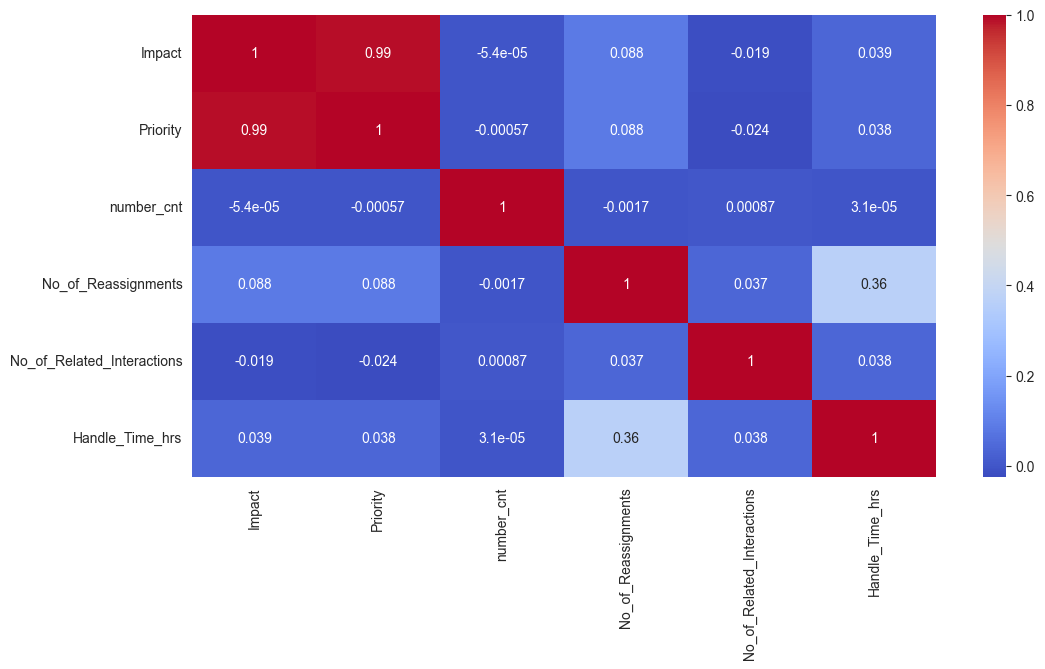

In [629]:
plt.figure(figsize=(12,6))
sns.heatmap(df[num_col].corr(),annot=True,cmap='coolwarm')

#### 1. Impact & Priority = Almost the same
#### 2. number_cnt has zero relationship
#### 3. No_of_Reassignment Correlation with Handle_Time_hrs = 0.36 -> weak relationship
#### 4. No_of_Related_Interactions --> Correlation with everything = ~0 --> useless --> drop()
#### 5. Handle_Time_hrs Weak correlation with Priority & Impact (0.03)

### Strong Relationship : Impact <---> Priority
### weak Relationship : No_of_Reassignment <---> Handle_Time_hrs

### dropping: No_of_Related_Interactions , number_cnt

In [630]:
df.drop(['No_of_Related_Interactions','number_cnt'],inplace=True,axis=1)

# Updating Categorical Columns
cat_col = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
cat_col


['CI_Cat', 'CI_Subcat', 'Category', 'Closure_Code', 'Is_Weekend']

# Summary

In [631]:
vz.quick_summary(df)

===== SIMPLE DATA SUMMARY =====
Rows       : 46606
Columns    : 17
Numeric    : 12
Categorical: 5
Datetime   : 0
Missing columns: 0
Duplicated rows: 438

Top Missing Columns (%):

Top Missing Categorical Columns (%):
  No missing categorical columns


In [632]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CI_Cat               46606 non-null  object 
 1   CI_Subcat            46606 non-null  object 
 2   Impact               46606 non-null  int64  
 3   Urgency              46606 non-null  int64  
 4   Priority             46606 non-null  float64
 5   Category             46606 non-null  object 
 6   No_of_Reassignments  46606 non-null  float64
 7   Closure_Code         46606 non-null  object 
 8   Handle_Time_hrs      46606 non-null  float64
 9   Ticket_Age           46606 non-null  int64  
 10  Open_Hour            46606 non-null  int32  
 11  Open_Day             46606 non-null  int32  
 12  Open_Month           46606 non-null  int32  
 13  Open_Year            46606 non-null  int32  
 14  Is_Weekend           46606 non-null  bool   
 15  is_network           46606 non-null 

# Encode Categorical Column (LabelEncoding)

In [633]:
from sklearn.preprocessing import LabelEncoder



le = LabelEncoder()

for col in cat_col:
    df[col] = le.fit_transform(df[col].astype(str))


In [634]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46606 entries, 0 to 46605
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CI_Cat               46606 non-null  int64  
 1   CI_Subcat            46606 non-null  int64  
 2   Impact               46606 non-null  int64  
 3   Urgency              46606 non-null  int64  
 4   Priority             46606 non-null  float64
 5   Category             46606 non-null  int64  
 6   No_of_Reassignments  46606 non-null  float64
 7   Closure_Code         46606 non-null  int64  
 8   Handle_Time_hrs      46606 non-null  float64
 9   Ticket_Age           46606 non-null  int64  
 10  Open_Hour            46606 non-null  int32  
 11  Open_Day             46606 non-null  int32  
 12  Open_Month           46606 non-null  int32  
 13  Open_Year            46606 non-null  int32  
 14  Is_Weekend           46606 non-null  int64  
 15  is_network           46606 non-null 

# Preparing Target

In [635]:
df["High_Priority"] = df["Priority"].apply(lambda x: 1 if x in [1, 2] else 0)


In [636]:
df[["High_Priority"]].value_counts()


High_Priority
0                45906
1                  700
Name: count, dtype: int64

![alt text](image-1.png)

## Selecting Features

In [637]:
X = df.drop(['Priority', 'Impact', 'Urgency', 'High_Priority'],axis=1)
y = df['High_Priority']

print(X.shape)
print(y.shape)

(46606, 14)
(46606,)


In [638]:
X.columns

Index(['CI_Cat', 'CI_Subcat', 'Category', 'No_of_Reassignments',
       'Closure_Code', 'Handle_Time_hrs', 'Ticket_Age', 'Open_Hour',
       'Open_Day', 'Open_Month', 'Open_Year', 'Is_Weekend', 'is_network',
       'is_app'],
      dtype='object')

## train test split

In [639]:
from sklearn.model_selection import train_test_split as tts 

X_train, X_test ,y_train , y_test = tts (X,y,test_size=0.2,random_state=42, stratify=y)

#  stratify=y -->  P1 and P2 ration will same during training

In [640]:
y.value_counts()

High_Priority
0    45906
1      700
Name: count, dtype: int64

# data is highly imbalanced ( let use SMOTE )

In [641]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train,y_train)

## Random Forest

In [642]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    # class_weight="balanced"

)
rf.fit(X_train_res,y_train_res)



,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluation

In [643]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9182
           1       0.38      0.52      0.44       140

    accuracy                           0.98      9322
   macro avg       0.69      0.75      0.71      9322
weighted avg       0.98      0.98      0.98      9322

Confusion Matrix:
[[9062  120]
 [  67   73]]


# Random Forest

In [644]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    max_depth=8,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=30   # because minority class is rare
)

xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [645]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test,y_pred_xgb))
print(roc_auc_score(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9182
           1       0.47      0.49      0.48       140

    accuracy                           0.98      9322
   macro avg       0.73      0.74      0.73      9322
weighted avg       0.98      0.98      0.98      9322

0.7386641565796433


### There are 4 target cols for 4 prediction problems
#### Predicting High Priority Tickets -> Priority
#### Forecast Incident Volume ->This becomes a time-series forecasting task (not done using Priority column). multicols 
#### Auto-tag Tickets (Classification) -> Priority | Category / CI_Cat / CI_Subcat (assign department)
#### Predict RFC / Change Failure -> Related_Change